In [1]:
# Block 1: Imports & setup

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import matplotlib.pyplot as plt

# Optional: make prints easier to read
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
# Block 2: Load data

DATA_PATH = Path("data.csv")  # change if needed

df = pd.read_csv(DATA_PATH)

print("Data shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Quick head to verify
df.head()

Data shape: (68628, 16)

Columns: ['time', 'latitude', 'longitude', 'chl', 'uo', 'vo', 'fe', 'no3', 'po4', 'si', 'o2', 'ph', 'so', 'spco2', 'thetao', 'wo']


,time,latitude,longitude,chl,uo,vo,fe,no3,po4,si,o2,ph,so,spco2,thetao,wo
0,2022-06-01,20.0,87.00,0.285966,0.143302,0.121338,0.001278,0.159255,0.000796,2.166951,199.42087,8.024398,32.915530,40.012962,30.360138,5.101815e-07
1,2022-06-01,20.0,87.25,0.198817,0.285533,0.187017,0.001213,0.101606,0.000353,2.187757,198.92993,8.025283,32.908985,40.026024,30.338413,7.922670e-07
2,2022-06-01,20.0,87.50,0.157684,0.528991,0.245835,0.001165,0.072593,0.000246,2.220604,198.51059,8.026939,32.663116,39.930134,30.338757,8.813758e-07
3,2022-06-01,20.0,87.75,0.139504,0.651719,0.226462,0.001127,0.055083,0.000191,2.244844,198.27168,8.028164,32.484990,39.835117,30.413069,-7.822748e-07
4,2022-06-01,20.0,88.00,0.133310,0.715622,0.208896,0.001118,0.053426,0.000180,2.251250,198.16145,8.028683,32.405870,39.793114,30.456890,1.493642e-06


In [3]:
# Block 3: Transform selected variables with log1p

log_features = ["fe", "no3", "po4", "si", "o2", "spco2"]

# Check all required columns exist
missing = [col for col in log_features if col not in df.columns]
if missing:
    raise ValueError(f"Missing columns in data for log transform: {missing}")

# Create log-transformed columns: <name>_log
for col in log_features:
    df[col + "_log"] = np.log1p(df[col])

# Quick check
df[[col for col in df.columns if col in log_features or col.endswith("_log")]].head()

,fe,no3,po4,si,o2,spco2,fe_log,no3_log,po4_log,si_log,o2_log,spco2_log
0,0.001278,0.159255,0.000796,2.166951,199.42087,40.012962,0.001278,0.147778,0.000795,1.152769,5.300420,3.713888
1,0.001213,0.101606,0.000353,2.187757,198.92993,40.026024,0.001212,0.096769,0.000353,1.159317,5.297967,3.714207
2,0.001165,0.072593,0.000246,2.220604,198.51059,39.930134,0.001164,0.070079,0.000246,1.169569,5.295867,3.711867
3,0.001127,0.055083,0.000191,2.244844,198.27168,39.835117,0.001127,0.053620,0.000191,1.177067,5.294669,3.709542
4,0.001118,0.053426,0.000180,2.251250,198.16145,39.793114,0.001118,0.052048,0.000180,1.179040,5.294116,3.708513


In [4]:
# Block 4: Prepare features and target

# Feature columns as used for prediction
FEATURE_COLS = [
    "uo",
    "vo",
    "fe_log",
    "no3_log",
    "po4_log",
    "si_log",
    "o2_log",
    "ph",
    "so",
    "spco2_log",
    "thetao",
    "wo",
]

TARGET_COL = "chl"

# Check required columns
missing_features = [c for c in FEATURE_COLS if c not in df.columns]
if missing_features:
    raise ValueError(f"Missing feature columns in data: {missing_features}")

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in data!")

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].values

X.head()

,uo,vo,fe_log,no3_log,po4_log,si_log,o2_log,ph,so,spco2_log,thetao,wo
0,0.143302,0.121338,0.001278,0.147778,0.000795,1.152769,5.300420,8.024398,32.915530,3.713888,30.360138,5.101815e-07
1,0.285533,0.187017,0.001212,0.096769,0.000353,1.159317,5.297967,8.025283,32.908985,3.714207,30.338413,7.922670e-07
2,0.528991,0.245835,0.001164,0.070079,0.000246,1.169569,5.295867,8.026939,32.663116,3.711867,30.338757,8.813758e-07
3,0.651719,0.226462,0.001127,0.053620,0.000191,1.177067,5.294669,8.028164,32.484990,3.709542,30.413069,-7.822748e-07
4,0.715622,0.208896,0.001118,0.052048,0.000180,1.179040,5.294116,8.028683,32.405870,3.708513,30.456890,1.493642e-06


In [5]:
# Block 5: Load trained XGBoost model and predict

MODEL_PATH = Path("models") / "xgb_model_no_kd.joblib"

# Load the model
model = joblib.load(MODEL_PATH)

# Predict chl using the model
y_pred = model.predict(X)

# Attach predictions to dataframe (optional)
df["chl_pred"] = y_pred

df[["chl", "chl_pred"]].head()

,chl,chl_pred
0,0.285966,0.267634
1,0.198817,0.181681
2,0.157684,0.177254
3,0.139504,0.146951
4,0.133310,0.138423


In [6]:
# Block 6: Compute performance metrics

r2 = r2_score(y, y_pred)

# older sklearn doesn't support squared=False
mse = mean_squared_error(y, y_pred)
rmse = mse ** 0.5

mae = mean_absolute_error(y, y_pred)

print(f"R² score: {r2:.4f}")
print(f"MSE:      {mse:.4f}")
print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")

R² score: 0.9274
MSE:      1.1325
RMSE:     1.0642
MAE:      0.4333


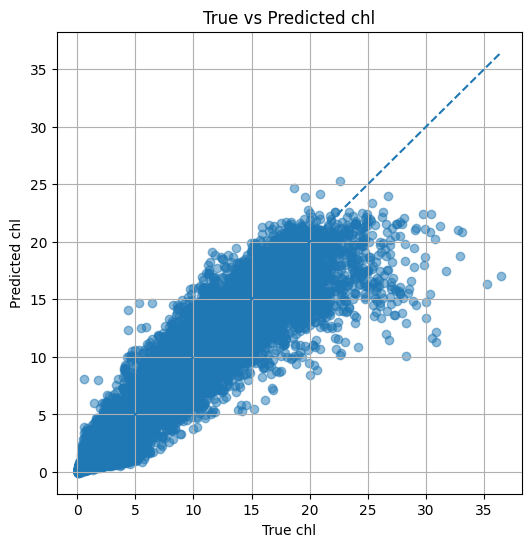

In [7]:
# Block 7: Scatter plot y vs y_pred

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.5)
plt.xlabel("True chl")
plt.ylabel("Predicted chl")
plt.title("True vs Predicted chl")
plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle="--")
plt.grid(True)
plt.show()